<a href="https://colab.research.google.com/github/Sristi-SS/rabi-oscillations-2levelsystem/blob/main/Rabi_Oscillations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

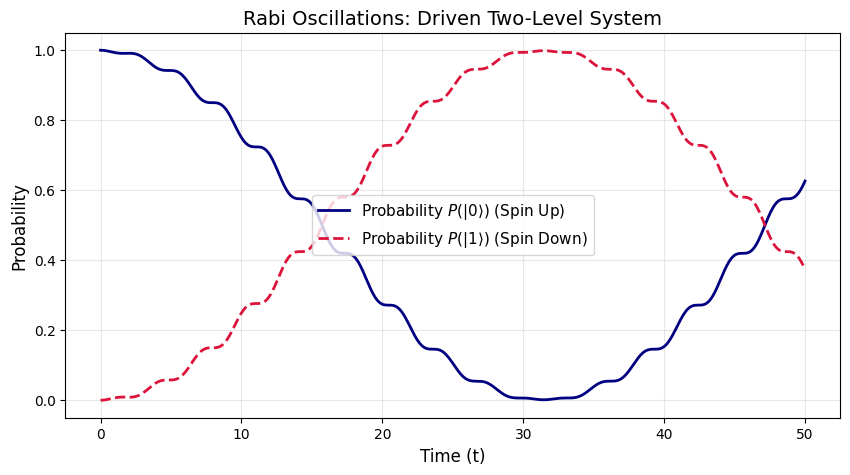

In [ ]:
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt

# --- Step 1: Define Pauli Matrices (Linear Algebra Setup) ---
# In Python, complex numbers use 'j' (e.g., 1j) instead of i
sigma_x = np.array([[0, 1],
                    [1, 0]], dtype=complex)

sigma_z = np.array([[1, 0],
                    [0, -1]], dtype=complex)

# --- Step 2: Set Physical Parameters ---
hbar = 1.0       # Natural units where hbar = 1
omega_0 = 1.0    # Resonant frequency of the two-level system
omega_1 = 0.1    # Strength of the driving field (Rabi frequency the flipping of an energy state between 2 energy levels)
omega_d = 1.0    # Frequency of the driving field (Try changing this!)

# --- Step 3: Set Initial Quantum State ---
# System starts in state |0> = [1, 0]^T (Spin Up)
psi = np.array([1.0 + 0j, 0.0 + 0j])

# --- Step 4: Time Setup ---
t_max = 50.0
steps = 1000
dt = t_max / steps
times = np.linspace(0, t_max, steps)

# Lists to track probabilities over time
prob_0 = []
prob_1 = []

# --- Step 5: Time Evolution Loop ---
for t in times:
    # 1. Calculate probability P(|0>) = |<0|psi>|^2 and P(|1>) = |<1|psi>|^2
    prob_0.append(np.abs(psi[0])**2)
    prob_1.append(np.abs(psi[1])**2)

    # 2. Construct time-dependent Hamiltonian H(t) = hw sigma_z  + h omega1 cos dt sigma x
    H = (hbar * omega_0 / 2.0) * sigma_z + (hbar * omega_1) * np.cos(omega_d * t) * sigma_x

    # 3. Compute Unitary Evolution Operator U = exp(-i * H * dt / hbar)
    # la.expm is matrix exponentiation (not element-wise exponentiation)
    U = la.expm(-1j * H * dt / hbar)

    # 4. Update state: |psi(t + dt)> = U @ |psi(t)> (@ denotes matrix-vector multiplication)
    psi = U @ psi # i nner product of two matrices

# --- Step 6: Visualization ---
plt.figure(figsize=(10, 5))
plt.plot(times, prob_0, label=r"Probability $P(|0\rangle)$ (Spin Up)", color="navy", linewidth=2)
plt.plot(times, prob_1, label=r"Probability $P(|1\rangle)$ (Spin Down)", color="crimson", linestyle="--", linewidth=2)
plt.xlabel("Time (t)", fontsize=12)
plt.ylabel("Probability", fontsize=12)
plt.title("Rabi Oscillations: Driven Two-Level System", fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()